In [ ]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
from tqdm import tqdm
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.metrics import balanced_accuracy_score
import anndata as ad
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

FIGURE_DIR = Path("../../book/book/images")

rng = np.random.default_rng(1234)

In [2]:
df_demographics = pd.read_csv('https://raw.githubusercontent.com/IanEisenberg/Self_Regulation_Ontology/refs/heads/master/Data/Complete_02-16-2019/demographics.csv', index_col=0).replace({'Sex': {0: 'Male', 1: 'Female'}})
variables_of_interest = ['Sex', 'Age', 'HighestEducation', 
       'HeightInches', 'WeightPounds','ArrestedChargedLifeCount',
       'CoffeeCupsPerDay', 'HouseholdIncome']
df_demographics = df_demographics[variables_of_interest]

df_measures = pd.read_csv('https://raw.githubusercontent.com/IanEisenberg/Self_Regulation_Ontology/refs/heads/master/Data/Complete_02-16-2019/meaningful_variables_clean.csv', index_col=0)
measures_of_interest = [
       'upps_impulsivity_survey.lack_of_perseverance',
       'upps_impulsivity_survey.lack_of_premeditation',
       'upps_impulsivity_survey.negative_urgency',
       'upps_impulsivity_survey.positive_urgency',
       'upps_impulsivity_survey.sensation_seeking',
        'ten_item_personality_survey.agreeableness',
       'ten_item_personality_survey.conscientiousness.ReflogTr',
       'ten_item_personality_survey.emotional_stability',
       'ten_item_personality_survey.extraversion',
       'ten_item_personality_survey.openness',
       'ravens.score',
       'cognitive_reflection_survey.correct_proportion'
]
df_measures = df_measures[measures_of_interest]
df_orig = df_demographics.join(df_measures, how='inner')


df_orig.head() 

,Sex,Age,HighestEducation,HeightInches,WeightPounds,ArrestedChargedLifeCount,CoffeeCupsPerDay,HouseholdIncome,upps_impulsivity_survey.lack_of_perseverance,upps_impulsivity_survey.lack_of_premeditation,upps_impulsivity_survey.negative_urgency,upps_impulsivity_survey.positive_urgency,upps_impulsivity_survey.sensation_seeking,ten_item_personality_survey.agreeableness,ten_item_personality_survey.conscientiousness.ReflogTr,ten_item_personality_survey.emotional_stability,ten_item_personality_survey.extraversion,ten_item_personality_survey.openness,ravens.score,cognitive_reflection_survey.correct_proportion
s001,Female,27,3,62,110,0.0,1.0,40000.0,1.5,1.909091,1.583333,2.142857,3.416667,4.5,0.916291,6.0,3.5,6.0,2.0,0.166667
s002,Male,35,2,72,240,0.0,3.0,19500.0,1.5,2.090909,3.000000,3.285714,3.083333,6.0,1.386294,6.0,5.0,6.5,4.0,0.166667
s003,Male,25,4,73,185,0.0,1.0,60000.0,2.4,2.363636,3.000000,2.785714,2.833333,5.5,0.916291,5.0,4.5,5.0,3.0,0.666667
s004,Male,35,4,71,190,0.0,0.0,81000.0,1.5,1.636364,1.583333,1.142857,1.916667,6.5,0.000000,7.0,3.0,4.0,9.0,0.666667
s005,Male,36,3,76,175,5.0,0.0,36000.0,1.7,1.363636,1.750000,1.000000,2.833333,6.0,1.098612,7.0,3.0,6.0,14.0,0.833333


### Negative controls

In [3]:
datadir = Path('/Users/poldrack/data_unsynced/BCBS/immune_aging')
datafile = datadir / 'wf_snakemake/checkpoints/dataset-OneK1K_step-07_desc-pseudobulk.h5ad'

adata = ad.read_h5ad(datafile)
adata

AnnData object with n_obs × n_vars = 4635 × 29515
    obs: 'cell_type', 'donor_id', 'n_cells', 'development_stage', 'sex', 'age', 'total_counts'

In [17]:
# filter by cell type
cell_type = 'central memory CD4-positive, alpha-beta T cell'
adata_ct = adata[adata.obs['cell_type'] == cell_type, :].copy()
adata_df = adata_ct.to_df()

# filter out subjects with low number of cells
n_cells_threshold = 100
sample_sums = adata_ct.obs['n_cells']
adata_df = adata_df.loc[sample_sums[sample_sums >= n_cells_threshold].index, :]
print('excluded samples:', sum(sample_sums < n_cells_threshold))

# filter out genes that are zero in any samples
gene_filter = (adata_df == 0).sum(axis=0) == 0
adata_df = adata_df.loc[:, gene_filter] 
adata_df['age'] = adata_ct.obs.loc[adata_df.index, 'age']
# label under 40 and over 70
adata_df['age_group'] = pd.cut(adata_df['age'], bins=[0, 40, 80, 120], labels=['under_40', '40_to_70', 'over_80'])
# remove age group '40_to_70' to have a clearer contrast
adata_df_full = adata_df.copy()
adata_df = adata_df[adata_df['age_group'] != '40_to_70']
adata_df.age_group.value_counts()

excluded samples: 17


age_group
under_40    112
over_80     111
40_to_70      0
Name: count, dtype: int64

In [5]:
adata_df.to_parquet(datadir / 'control_experiment_central_memory_CD4_T_cells.parquet')

In [6]:
adata_df = pd.read_parquet(datadir / 'control_experiment_central_memory_CD4_T_cells.parquet')
# subsample from each group to have balanced classes
n_per_class = 16
adata_df = pd.concat([
    adata_df[adata_df['age_group'] == 'under_40'].sample(n_per_class, random_state=rng),
    adata_df[adata_df['age_group'] == 'over_80'].sample(n_per_class, random_state=rng)
])

adata_df.shape


(32, 4214)

set up predictive model using a randomly generated disease outcome.

In [ ]:


def run_classifier(X, y, model, cv, shuffle_y=False, 
                    scorer=None, rng=None, scale_X=True,
                    nfeatures_to_select=10,
                    bad_feature_selection=False):
    """
    Run a classifier with cross-validation, optionally shuffling the target labels.
    also do scaling and feature selection within each fold
    """
    if shuffle_y:
        if rng is None:
            rng = np.random.default_rng()
        y = rng.permutation(y)

    if scorer is None:
        scorer = balanced_accuracy_score

    if bad_feature_selection:
        # feature selection outside of CV (this is bad practice)
        selector = f_classif
        f_values, p_values = selector(X, y)
        top_k_indices = np.argsort(f_values)[-nfeatures_to_select:]
        X = X[:, top_k_indices]

    results = {}
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if scale_X:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
 
        if nfeatures_to_select is not None and not bad_feature_selection:
            # feature selection using ANOVA F-test
            selector = f_classif
            f_values, p_values = selector(X_train, y_train)
            # select top 100 features
            top_k_indices = np.argsort(f_values)[-nfeatures_to_select:]

            X_train = X_train[:, top_k_indices]
            X_test = X_test[:, top_k_indices]

       
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_train = model.predict(X_train)

        score_value = scorer(y_test, y_pred)
        train_score_value = scorer(y_train, y_pred_train)
        scorer_name = scorer.__name__.replace('_score', '')
        if f'test_{scorer_name}' not in results:
            results[f'test_{scorer_name}'] = [] 
        results[f'test_{scorer_name}'].append(score_value)
        if f'train_{scorer_name}' not in results:
            results[f'train_{scorer_name}'] = []
        results[f'train_{scorer_name}'].append(train_score_value)

    # compute mean scores across folds
    means = {k: np.mean(v) for k, v in results.items()}
    return means

n_simulations = 5000
results = []
results_bad_fs = []

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.4)

model = SGDClassifier(n_jobs=-1)

over80 = (adata_df['age_group'].values == 'over_80').astype(int)
X = adata_df.drop(columns=['age', 'age_group']).to_numpy()
# do feature selection using VarianceThreshold


y = over80

print('Original data:')
true_result = run_classifier(X, y, model, cv,
        shuffle_y=False, rng=rng)
print(f'Balanced_accuracy: {true_result["test_balanced_accuracy"]:.3f}')
true_result_bad_fs = run_classifier(X, y, model, cv,
        shuffle_y=False, rng=rng,
        bad_feature_selection=True)
print(f'Balanced_accuracy with invalid feature selection: {true_result_bad_fs["test_balanced_accuracy"]:.3f}')

# run simulations with shuffled labels
for i in tqdm(range(n_simulations)):
    proportion_positive = 0.5
    # random binary target
    rng = np.random.default_rng() #i)
    #y = rng.choice([0, 1], size=n_samples, 
    #    p=[1 - proportion_positive, proportion_positive])

    results.append(run_classifier(X, y, model, cv,
        shuffle_y=True, rng=rng))
    results_bad_fs.append(run_classifier(X, y, model, cv,
        shuffle_y=True, rng=rng,
        bad_feature_selection=True))

results_df = pd.DataFrame(results)
results_bad_fs_df = pd.DataFrame(results_bad_fs)


method = 'balanced_accuracy'
print('\nResults using shuffled y labels:')
rand_pval = 1 - np.mean(true_result[f"test_{method}"] > results_df[f'test_{method}'])
print(f'p-value for original data versus shuffled: {rand_pval:.3f}')
print(f'Shuffled {method} with valid feature selection: mean={results_df[f"test_{method}"].mean():.3f}, std={results_df[f"test_{method}"].std():.3f}')
print(f'Shuffled {method} with invalid feature selection: mean={results_bad_fs_df[f"test_{method}"].mean():.3f}, std={results_bad_fs_df[f"test_{method}"].std():.3f}')
print(f'Shuffled training {method}: mean={results_df[f"train_{method}"].mean():.3f}, std={results_df[f"train_{method}"].std():.3f}')

# t-test verus 0.5 for balanced accuracy on shuffled data with and without bad feature selection

from scipy.stats import ttest_1samp
tstat, pval = ttest_1samp(results_df[f'test_{method}'], 0.5)
print(f'T-test versus 0.5 for balanced accuracy on shuffled data with valid feature selection: t={tstat:.3f}, p={pval:.3f}')
tstat, pval = ttest_1samp(results_bad_fs_df[f'test_{method}'], 0.5)
print(f'T-test versus 0.5 for balanced accuracy on shuffled data with bad feature selection: t={tstat:.3f}, p={pval:.3f}')


Original data:
Balanced_accuracy: 0.560
Balanced_accuracy with invalid feature selection: 0.671


100%|██████████| 5000/5000 [01:34<00:00, 52.98it/s]


Results using shuffled y labels:
p-value for original data versus shuffled: 0.214
Shuffled balanced_accuracy with valid feature selection: mean=0.498, std=0.077
Shuffled balanced_accuracy with invalid feature selection: mean=0.614, std=0.119
Shuffled training balanced_accuracy: mean=0.905, std=0.055
T-test versus 0.5 for balanced accuracy on shuffled data with valid feature selection: t=-1.449, p=0.147
T-test versus 0.5 for balanced accuracy on shuffled data with bad feature selection: t=67.896, p=0.000


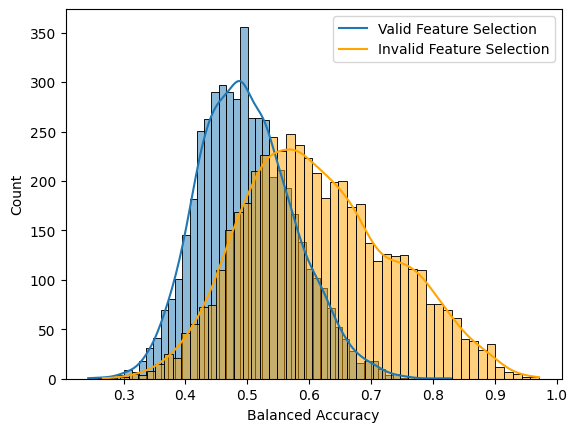

In [16]:


sns.histplot(results_df[f'test_balanced_accuracy'], bins=50, kde=True)
# overlay bad feature selection
sns.histplot(results_bad_fs_df[f'test_balanced_accuracy'], bins=50, kde=True, color='orange')
plt.xlabel('Balanced Accuracy')
plt.legend(['Valid Feature Selection', 'Invalid Feature Selection'])
plt.savefig(FIGURE_DIR / 'control_experiment_balanced_accuracy_histogram.png', dpi=300)

### positive control example

let's say we want to generate a biomarker based on RNA-seq for a disease that is present in 10% of the population.  We can use the RNA-seq data from the full sample in the earlier study (910 individuals). 

In [ ]:
X.shape


(910, 4212)

In [167]:
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
from sklearn.feature_selection import SelectFdr

def run_signal_injection(X, y, beta=None, model=None, cv=None, shuffle_y=False, 
                    scorer=None, rng=None, scale_X=True,
                    nfeatures_to_select=1000, sim_features=10,
                    n_splits=10, disease_prevalence=0.1, noise_sd=1.0):
    """
    Run a regression with cross-validation, optionally shuffling the target labels.
    also do scaling and feature selection within each fold

    to generate synthetic data with known coefficients, provide beta, which will automatically generate y after shuffling

    """
    if model is None:
        model = SGDClassifier(n_jobs=-1)

    if cv is None:
        cv = StratifiedShuffleSplit(n_splits=n_splits, test_size=0.3)
    
    if rng is None:
        rng = np.random.default_rng()
        
    if shuffle_y:
        y = rng.permutation(y)

    if scorer is None:
        scorer = balanced_accuracy_score

    # convert to numpy arrays
    X = np.array(X)
    y = np.array(y)
    
    if beta is not None:
        # set sim_features to be non-zero
        X_regressor = np.zeros(X.shape[1])
        X_regressor[:sim_features] = beta
        np.random.shuffle(X_regressor)
        y_continuous = X @ X_regressor + rng.normal(0, noise_sd, size=y.shape)
        # binarize by based prevalence
        threshold = np.percentile(y_continuous, 100 * (1-disease_prevalence))
        y = (y_continuous >= threshold).astype(int)

    results = {}
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if scale_X:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
 
        if nfeatures_to_select is not None:
            # feature selection using ANOVA F-test
            selector = f_classif
            f_values, p_values = selector(X_train, y_train)
            # select top 100 features
            top_k_indices = np.argsort(f_values)[-nfeatures_to_select:]
            X_train = X_train[:, top_k_indices]
            X_test = X_test[:, top_k_indices]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_train = model.predict(X_train)

        score_value = scorer(y_test, y_pred)
        train_score_value = scorer(y_train, y_pred_train)
        scorer_name = scorer.__name__.replace('_score', '')
        if f'test_{scorer_name}' not in results:
            results[f'test_{scorer_name}'] = [] 
        results[f'test_{scorer_name}'].append(score_value)
        if f'train_{scorer_name}' not in results:
            results[f'train_{scorer_name}'] = []
        results[f'train_{scorer_name}'].append(train_score_value)
        results['nfeatures_selected'] = X_train.shape[1]

    # compute mean scores across folds
    means = {k: np.mean(v) for k, v in results.items()}
    return means



In [169]:
from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import SGDRegressor
from sklearn.feature_selection import f_regression

X = adata_df_full.drop(columns=['age', 'age_group']).to_numpy()

print('Regression on age with full dataset:')
run_signal_injection(X, y)

Regression on age with full dataset:


{'test_balanced_accuracy': np.float64(0.3376041973129352),
 'train_balanced_accuracy': np.float64(0.9515015015015015),
 'nfeatures_selected': np.float64(1000.0)}

In [ ]:
rng = np.random.default_rng(1234)
n_simulations = 1000
fdr_fsel = 0.1

results = {}
for beta in np.arange(0, 0.0055, 0.0005):
    for nfeatures in [10, 25, 50]:
        print(f'\nDisease classification on synthetic data, beta={beta:.4f}, nfeatures={nfeatures}:')
        n_features = X.shape[1]
        result = []
        for i in range(n_simulations):
            result.append(run_signal_injection(X, y, beta=beta, 
                sim_features=nfeatures))
        results[(beta, nfeatures)] = pd.DataFrame(result)
        results[(beta, nfeatures)]['beta'] = beta
        results[(beta, nfeatures)]['nfeatures'] = nfeatures
        print(f'Balanced_accuracy: mean={results[(beta, nfeatures)]["test_balanced_accuracy"].mean():.3f}, std={results[(beta, nfeatures)]["test_balanced_accuracy"].std():.3f}, nfeatures_selected={results[(beta, nfeatures)]["nfeatures_selected"].mean():.1f}')
results_df = pd.concat(results.values())
results_df.head()

results_df.to_csv(datadir / 'positive_control_beta_nfeatures.csv', index=False)


Disease classification on synthetic data, beta=0.0000, nfeatures=10:


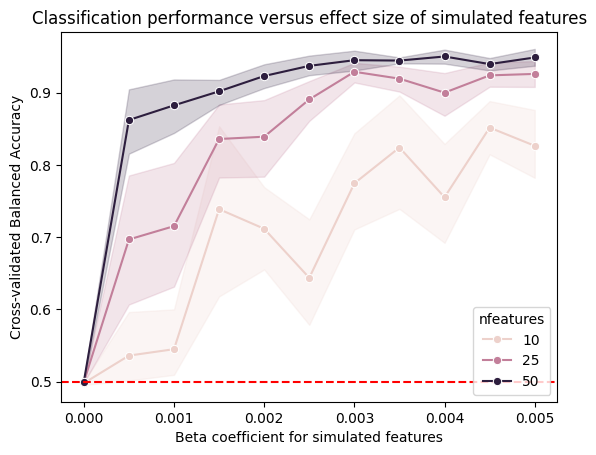

In [160]:
# plot mean R2 versus beta
# first concatenate results
all_results = pd.concat(results.values())

sns.lineplot(data=all_results, x='beta', y='test_balanced_accuracy', hue='nfeatures', 
    marker='o')
plt.xlabel('Beta coefficient for simulated features')
plt.ylabel('Cross-validated Balanced Accuracy')
plt.title('Classification performance versus effect size of simulated features')

plt.axhline(0.5, color='red', linestyle='--')
plt.savefig(FIGURE_DIR / 'control_experiment_classification_balanced_accuracy_vs_beta.png', dpi=300)

assess performance as a function of sample size

In [ ]:

nfeatures = 20

results = {}
for beta in np.arange(0, 0.0055, 0.0005):
    for sample_size in [100, 200, 500, adata_df_full.shape[0]]:
        print(f'\nDisease classification on synthetic data, beta={beta:.4f}, sample size={sample_size}:')
        result = []
        # get a set of samples randomly selected from the full dataset
        adata_df_sample = adata_df_full.sample(sample_size, random_state=rng)
        X = adata_df_sample.drop(columns=['age', 'age_group']).to_numpy()
        y = adata_df_sample['age_group'].to_numpy()
    
        for i in range(n_simulations):
            result.append(run_signal_injection(
                X, y, beta=beta, 
                sim_features=nfeatures))
        results[(beta, sample_size)] = pd.DataFrame(result)
        results[(beta, sample_size)]['beta'] = beta
        results[(beta, sample_size)]['sample_size'] = sample_size
        results[(beta, sample_size)]['nfeatures'] = nfeatures

        print(f'Balanced_accuracy: mean={results[(beta, sample_size)]["test_balanced_accuracy"].mean():.3f}, std={results[(beta, sample_size)]["test_balanced_accuracy"].std():.3f}, nfeatures_selected={results[(beta,         
            sample_size)]["nfeatures_selected"].mean():.1f}')

results_df = pd.concat(results.values())
results_df.head()

results_df.to_csv(datadir / 'positive_control_beta_sample_size.csv', index=False)


Disease classification on synthetic data, beta=0.0000, sample size=200:
Balanced_accuracy: mean=0.497, std=0.007, nfeatures_selected=4128.5

Disease classification on synthetic data, beta=0.0000, sample size=500:
Balanced_accuracy: mean=0.499, std=0.007, nfeatures_selected=4212.0

Disease classification on synthetic data, beta=0.0000, sample size=910:
Balanced_accuracy: mean=0.499, std=0.006, nfeatures_selected=4000.1

Disease classification on synthetic data, beta=0.0005, sample size=200:
Balanced_accuracy: mean=0.648, std=0.120, nfeatures_selected=4201.3

Disease classification on synthetic data, beta=0.0005, sample size=500:
Balanced_accuracy: mean=0.675, std=0.127, nfeatures_selected=4209.4

Disease classification on synthetic data, beta=0.0005, sample size=910:
Balanced_accuracy: mean=0.695, std=0.170, nfeatures_selected=4211.8

Disease classification on synthetic data, beta=0.0010, sample size=200:
Balanced_accuracy: mean=0.763, std=0.123, nfeatures_selected=4208.3

Disease clas

,test_balanced_accuracy,train_balanced_accuracy,nfeatures_selected,beta,sample_size
0,0.489023,0.936932,3377.0,0.0,200
1,0.487068,0.942234,4212.0,0.0,200
2,0.497222,0.939103,4212.0,0.0,200
3,0.486178,0.982441,4212.0,0.0,200
4,0.496154,0.957112,4212.0,0.0,200


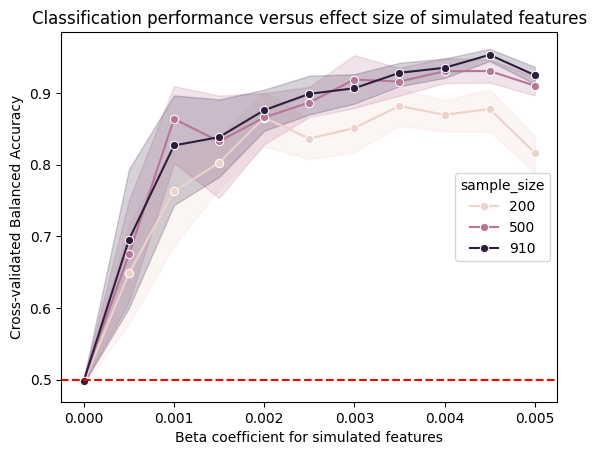

In [164]:
all_results = pd.concat(results.values())

sns.lineplot(data=all_results, x='beta', y='test_balanced_accuracy', hue='sample_size', 
    marker='o')
plt.xlabel('Beta coefficient for simulated features')
plt.ylabel('Cross-validated Balanced Accuracy')
plt.title('Classification performance versus effect size of simulated features')

plt.axhline(0.5, color='red', linestyle='--')
plt.savefig(FIGURE_DIR / 'control_experiment_classification_sample_size.png', dpi=300)